In [19]:
import sys
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import gymnasium as gym
from gymnasium.spaces import Dict, MultiDiscrete, Box
from sb3_contrib import MaskablePPO
from sb3_contrib.common.maskable.callbacks import MaskableEvalCallback
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.env_util import make_vec_env
import numpy as np
from scipy.signal import convolve2d
from typing import Literal
from src.config import (
    LAND_COVER_LABELS, PROTECTED_CLASSES, ECONOMIC_VALUES, ET_VALUES,
    N_CLASSES, N_PIXELS_PER_CELL, SAMPLE_SIZE, GRID_KWARGS, SEED, data_dir, log_dir, model_dir, CENTER
)
import importlib
from src.utils import minmax_normalize, get_logger
import wandb
from wandb.integration.sb3 import WandbCallback
from datetime import date

logger = get_logger(__name__, log_file=Path(log_dir, f"{date.today():%m%d}-v2.log"), stream=False, level="DEBUG")

# ── Mock ET cost per land-cover class (mm / year) ──────────────────────
# NOT USED
ET_VALUES = {
    1:  0,   # Water        – minimal (surface evaporation counted elsewhere)
    2:  0,   # Trees        – moderate transpiration
    4:  0,   # Flooded      – similar to open water
    5:  0,   # Crops        – irrigation-heavy
    7:  0,   # Built Area   – low (impervious surface)
    8:  0,    # Bare Ground  – very low
    9:  0,     # Snow/Ice     – negligible
    10: 0,     # Clouds       – N/A
    11: 0,   # Rangeland    – moderate
}

norm_et_cost = minmax_normalize(ET_VALUES)
norm_eco_values = minmax_normalize(ECONOMIC_VALUES)

# Build dense arrays for vectorised reward computation
ECO_PER_CLASS = np.zeros(N_CLASSES, dtype=np.float32)
ET_PER_CLASS  = np.zeros(N_CLASSES, dtype=np.float32)
for _cls, _val in norm_eco_values.items():
    if _cls < N_CLASSES:
        ECO_PER_CLASS[_cls] = _val
for _cls, _val in norm_et_cost.items():
    if _cls < N_CLASSES:
        ET_PER_CLASS[_cls] = _val

# Modifiable (non-protected) land-cover classes
MODIFIABLE_CLASSES = sorted(set(range(N_CLASSES)) - PROTECTED_CLASSES)
N_MOD = len(MODIFIABLE_CLASSES)

# Sliced value vectors for modifiable classes only (length N_MOD)
ECO_MOD = ECO_PER_CLASS[MODIFIABLE_CLASSES]
ET_MOD  = ET_PER_CLASS[MODIFIABLE_CLASSES]
""
print(f"All classes       : {list(LAND_COVER_LABELS.items())}")
print(f"Protected classes : {PROTECTED_CLASSES}")
print(f"Modifiable classes: {MODIFIABLE_CLASSES}  (n={N_MOD})")
print(f"Pixels per cell   : {N_PIXELS_PER_CELL}")
print(f"Grid size per ep  : {SAMPLE_SIZE}×{SAMPLE_SIZE}")

All classes       : [(1, 'Water'), (2, 'Trees'), (4, 'Flooded'), (5, 'Crops'), (7, 'Built Area'), (8, 'Bare Ground'), (9, 'Snow/Ice'), (10, 'Clouds'), (11, 'Rangeland')]
Protected classes : frozenset({0, 1, 3, 4, 6, 9, 10})
Modifiable classes: [2, 5, 7, 8, 11]  (n=5)
Pixels per cell   : 25
Grid size per ep  : 10×10


In [20]:
print(ECO_MOD)
print(ET_MOD)
print(ECO_MOD + ET_MOD)

[0.2095 0.2165 0.2597 0.     0.162 ]
[0. 0. 0. 0. 0.]
[0.2095 0.2165 0.2597 0.     0.162 ]


In [21]:
ECO_PER_CLASS

array([0.    , 0.4877, 0.2095, 0.    , 1.    , 0.2165, 0.    , 0.2597,
       0.    , 0.    , 0.    , 0.162 ], dtype=float32)

In [22]:
def augment_data(data, size, seed, split='train_indices', n_augment=10):
    if split == 'no_split':
        indices = np.concatenate((data['train_indices'], data['test_indices']), axis=0)
    else:
        indices = data[split]

    pixel_counts = data['pixel_counts']
    samples = np.stack([
        pixel_counts[i[0]:i[0]+size, i[1]:i[1]+size]
        for i in indices
    ])
    rng = np.random.default_rng(seed)

    if n_augment > 0:
        n_rows, n_cols = pixel_counts.shape[:2]
        for _ in range(n_augment):
            augmented = []
            for i in indices:
                dr = rng.integers(-2, 3)
                dc = rng.integers(-2, 3)
                r0 = np.clip(i[0] + dr, 0, n_rows - size)
                c0 = np.clip(i[1] + dc, 0, n_cols - size)
                augmented.append(pixel_counts[r0:r0+size, c0:c0+size])
            samples = np.concatenate([samples, np.stack(augmented)])
    return samples

In [23]:
data = np.load(Path(data_dir, "processed", "rl_dataset.npz"))
samples = augment_data(data, 10, SEED, split='no_split')
samples.shape

(275, 10, 10, 12)

In [24]:
from posixpath import split

# Number of pixels to transfer per action
PIXELS_PER_TRANSFER = 5

# Max consecutive no-ops before early termination (Option B)
MAX_CONSECUTIVE_NOOPS = 10


class LandUseEnv(gym.Env):
    """
    RL Environment for land-use allocation optimization.

    State:  (size, size, N_MOD) fractions of MODIFIABLE land-cover types [0, 1]
    Action: [row, col, source_class, target_class] - transfer pixels from source to target
    Reward: Change in total value with spatial modifiers and ET penalty
    """
    metadata = {"render_modes": []}

    def __init__(self, size=10, max_steps=500,
                 split: Literal['train_indices', 'test_indices', 'no_split'] = 'train_indices',
                 add_spatial_reward=True, lambda_cont=0.5, lambda_buf=2.0,
                 lambda_et=1.0, reward_scale=1.0, n_augment=10,
                 et_dcs_tolerance=0.1, min_mod_frac=0.1):
        super().__init__()
        self.size = size
        self.max_steps = max_steps
        self.lambda_et = lambda_et
        self.reward_scale = reward_scale
        self.data = np.load(Path(data_dir, "processed", "rl_dataset.npz"))
        self.split = split
        self.initial_total_et = 0.0
        self.add_spatial_reward = add_spatial_reward
        self.lambda_cont = lambda_cont
        self.lambda_buf = lambda_buf
        self.n_augment = n_augment
        self.et_dcs_tolerance = et_dcs_tolerance
        self.min_mod_frac = min_mod_frac

        self._mod_idx = {cls: i for i, cls in enumerate(MODIFIABLE_CLASSES)}

        self.observation_space = Box(
            low=0.0, high=1.0,
            shape=(size, size, N_MOD),
            dtype=np.float32
        )

        # Action: [row, col, source_class_idx, target_class_idx]
        self.action_space = MultiDiscrete([size, size, N_MOD, N_MOD])

        self.state = None
        self.step_count = 0
        self.consecutive_noops = 0
        self.prev_total_value = 0.0

    def action_masks(self) -> np.ndarray:
        """
        Flat bool mask for MaskablePPO with MultiDiscrete([size, size, N_MOD, N_MOD]).
        - Row/Col: all valid
        - Source: valid if any cell globally has >0 fraction for that class
        - Target: valid if any cell globally has <1.0 fraction for that class
        """
        row_mask = np.ones(self.size, dtype=bool)
        col_mask = np.ones(self.size, dtype=bool)

        source_mask = np.array([np.any(self.state[:, :, k] > 0) for k in range(N_MOD)])
        target_mask = np.array([np.any(self.state[:, :, k] < 1.0) for k in range(N_MOD)])

        if not source_mask.any():
            source_mask[:] = True
        if not target_mask.any():
            target_mask[:] = True

        return np.concatenate([row_mask, col_mask, source_mask, target_mask])

    def _compute_total_value(self):
        net_values = self.state * (ECO_MOD + ET_MOD)
        if self.add_spatial_reward:
            spatial_reward, contiguity_bonus, buffer_penalty = self._compute_spatial_modifiers()
        else:
            spatial_reward = contiguity_bonus = buffer_penalty = 0
        total_values = float(net_values.sum()) + spatial_reward
        return total_values, spatial_reward, contiguity_bonus, buffer_penalty

    def _compute_total_et(self) -> float:
        return float((self.state.reshape(-1, N_MOD) @ ET_MOD).sum())

    def _compute_spatial_modifiers(self):
        fractions = self.state
        kernel = np.array([[0, 1, 0],
                           [1, 0, 1],
                           [0, 1, 0]])

        trees = fractions[:, :, self._mod_idx[2]]
        tree_neighbors = convolve2d(trees, kernel, mode='same', boundary='fill', fillvalue=0)
        contiguity_bonus = np.sum(trees * tree_neighbors)

        water_bodies = self._protected_water
        high_impact = fractions[:, :, self._mod_idx[5]] + fractions[:, :, self._mod_idx[7]]
        water_neighbors = convolve2d(water_bodies, kernel, mode='same', boundary='fill', fillvalue=0)
        buffer_penalty = np.sum(high_impact * water_neighbors)

        spatial_reward = (self.lambda_cont * contiguity_bonus) - (self.lambda_buf * buffer_penalty)
        return float(spatial_reward), contiguity_bonus, buffer_penalty

    def _get_obs(self, idx) -> np.ndarray:
        raw = self.samples[idx]
        mod_counts = raw[:, :, MODIFIABLE_CLASSES]
        self.state = mod_counts.astype(np.float32) / N_PIXELS_PER_CELL
        self._protected_water = (raw[:, :, 1] + raw[:, :, 4]).astype(np.float32) / N_PIXELS_PER_CELL
        return self.state

    def _apply_action(self, action):
        """
        Transfer PIXELS_PER_TRANSFER pixels from source to target in selected cell.
        Inherently zero-sum. Returns True if transfer applied, False if no-op.
        """
        r, c, source_idx, target_idx = action
        logger.debug(f"Attempted action: ({r}, {c}) transfer from class {MODIFIABLE_CLASSES[source_idx]} to {MODIFIABLE_CLASSES[target_idx]}")

        if source_idx == target_idx:
            logger.debug(f"No-op action due to: source_idx {source_idx} == target_idx {target_idx}")
            return False

        cell = self.state[r, c, :]
        transfer = PIXELS_PER_TRANSFER / N_PIXELS_PER_CELL

        actual = min(transfer, float(cell[source_idx]), 1.0 - float(cell[target_idx]))

        if actual <= 0:
            logger.debug(f"No-op action due to: actual transfer {actual} <= 0")
            return False

        cell[source_idx] -= actual
        cell[target_idx] += actual
        logger.debug(f"Applied action: ({r}, {c}) transfer {actual:.4f} from class {MODIFIABLE_CLASSES[source_idx]} to {MODIFIABLE_CLASSES[target_idx]}")
        return True

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.samples = augment_data(self.data, size=self.size, seed=seed, split=self.split, n_augment=self.n_augment)

        n_cells = self.size * self.size
        for _ in range(100):
            idx = self.np_random.integers(self.samples.shape[0] - 1)
            self.state = self._get_obs(idx).copy()
            mod_frac = np.count_nonzero(self.state.sum(axis=2)) / n_cells
            if mod_frac >= self.min_mod_frac:
                break

        self.step_count = 0
        self.consecutive_noops = 0
        self.prev_total_value, _, _, _ = self._compute_total_value()
        self.initial_total_et = self._compute_total_et()
        info = {"total_value": self.prev_total_value, "et_decrease": 0.0, "step": self.step_count}
        logger.info(f'Reset env: mod_frac={mod_frac:.2f}, {info}')
        return self.state, info

    def step(self, action):
        logger.debug(f'Step {self.step_count}')
        applied = self._apply_action(action)

        if not applied:
            self.consecutive_noops += 1
        else:
            self.consecutive_noops = 0

        cur_total_value, spatial_reward, contiguity_bonus, buffer_penalty = self._compute_total_value()

        reward = cur_total_value - self.prev_total_value
        self.prev_total_value = cur_total_value
        self.step_count += 1

        et_decrease = (self.initial_total_et - self._compute_total_et()) / (self.initial_total_et + 1e-9)
        # et_penalty = self.lambda_et * max(0.0, et_decrease)
        # reward -= et_penalty

        reward /= self.reward_scale

        terminated = (self.step_count >= self.max_steps
                      or et_decrease >= self.et_dcs_tolerance
                      or self.consecutive_noops >= MAX_CONSECUTIVE_NOOPS)
        truncated = False
        info = {
            "total_value": cur_total_value,
            "et_decrease": et_decrease,
            "step": self.step_count,
            "contiguity_bonus": contiguity_bonus,
            "buffer_penalty": buffer_penalty,
            "spatial_reward": spatial_reward,
        }
        if self.consecutive_noops >= MAX_CONSECUTIVE_NOOPS:
            logger.info(f'Early termination: {MAX_CONSECUTIVE_NOOPS} consecutive no-ops at step {self.step_count}')
        logger.info(f'Step {self.step_count} result: reward={reward:.4f}, terminated={terminated}, info={info}')
        return self.state, reward, terminated, truncated, info

In [25]:
delta_boundary = 1
delta_choices = 2 * delta_boundary + 1
action_space = MultiDiscrete([10, 10] + [delta_choices] * N_MOD)
action_space.sample()

array([9, 8, 1, 0, 2, 1, 1])

In [26]:
import torch
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class GridCNN(BaseFeaturesExtractor):
    """
    Custom CNN feature extractor for training sample, e.g. 10x10xN_MOD grid observations.
    
    Uses small 3x3 kernels designed for the grid, preserving spatial adjacency that the contiguity
    and buffer reward terms depend on.
    
    Architecture:
        Conv1: N_MOD ch → conv1_features_out channel, 3x3, pad=1, stride=1 -> 10*10*32
        Conv2: conv1_features_out ch → conv2_features_out ch, 3x3, pad=1, stride=2 -> 5*5*64
        FC → features_out
    """
    def __init__(self, observation_space, conv1_features_out=32, conv2_features_out=64, features_out=128):
        super().__init__(observation_space, features_out)
        self.conv1_features_out = conv1_features_out
        self.conv2_features_out = conv2_features_out
        n_channels = observation_space.shape[-1]  # N_MOD
        
        self.cnn = nn.Sequential(
            nn.Conv2d(n_channels, self.conv1_features_out, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(self.conv1_features_out, self.conv2_features_out, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )

        with torch.no_grad():
            dummy_input = torch.zeros(1, n_channels, observation_space.shape[0], observation_space.shape[1])
            n_flatten = self.cnn(dummy_input).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, features_out),
            nn.ReLU(),
        )
    
    def forward(self, observations):
        # SB3 provides (batch, H, W, C); PyTorch Conv2d needs (batch, C, H, W)
        x = observations.permute(0, 3, 1, 2).float()
        return self.linear(self.cnn(x))

# Quick shape sanity check
_dummy_obs = torch.randn(1, 10, 10, N_MOD)
_extractor = GridCNN(Box(low=0.0, high=1.0, shape=(10, 10, N_MOD), dtype=np.float32), features_out=128)
_out = _extractor(_dummy_obs)
print(f"GridCNN: input {tuple(_dummy_obs.shape)} → output {tuple(_out.shape)}")
del _dummy_obs, _extractor, _out

GridCNN: input (1, 10, 10, 5) → output (1, 128)


In [27]:
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np

# Log metrics in WandB cloud
class SpatialMetricsCallback(BaseCallback):
    """
    Custom callback for logging spatial environment metrics from the info dict.
    """
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.contiguity_buffer = []
        self.penalty_buffer = []
        self.et_decrease_buffer = []

    def _on_step(self) -> bool:
        # extract the info dict from the current step
        # self.locals["infos"] is a list because SB3 vectorizes environments
        for info in self.locals.get("infos", []):
            if "contiguity_bonus" in info:
                self.contiguity_buffer.append(info["contiguity_bonus"])
            if "buffer_penalty" in info:
                self.penalty_buffer.append(info["buffer_penalty"])
            if "et_decrease" in info:
                self.et_decrease_buffer.append(info["et_decrease"])
        return True
        
    def _on_rollout_end(self) -> None:
        # log the mean of the metrics at the end of every rollout
        if self.contiguity_buffer:
            self.logger.record("spatial/contiguity_bonus_mean", np.mean(self.contiguity_buffer))
            self.contiguity_buffer = []
            
        if self.penalty_buffer:
            self.logger.record("spatial/buffer_penalty_mean", np.mean(self.penalty_buffer))
            self.penalty_buffer = []
        
        if self.et_decrease_buffer:
            self.logger.record("spatial/et_decrease_mean", np.mean(self.et_decrease_buffer))
            self.et_decrease_buffer = []

In [ ]:
config = {
    "policy_type": "MlpPolicy",  
    "features_extractor": "GridCNN",
    "features_out": 128,
    "env_name": "LakeMalawiLandUse-v0",
    "total_timesteps": 500_000, # 500_000,
    "n_steps": 2048,
    "batch_size": 128,         
    "n_epochs": 10, 
    "learning_rate": 3e-4,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_range": 0.2,
    "ent_coef": 0.02,              
    "vf_coef": 0.5,
    "max_grad_norm": 0.5,
    "max_steps": 500, # 500
    "lambda_cont": 0.05,
    "lambda_buf": 0.05,         
    "lambda_et": 1.0,
    "reward_scale": 1.0,
    "n_augment": 5,     
    "et_dcs_tolerance": 1,
    "add_spatial_reward": True
}

# set customized arch for Actor-Critic net
policy_kwargs = dict(
    features_extractor_class=GridCNN,  # use customized extractor instead of the default flatten layer
    features_extractor_kwargs=dict(features_out=config["features_out"]),
    # # no MLP layers - CNN output goes straight to action/value heads, e.g. Linear(features_out → action_dim/value_dim)
    # net_arch=[]
    share_features_extractor=True,
)

In [ ]:
# initialize WandB
run = wandb.init(
    project="CS8903-odc",
    config=config,
    sync_tensorboard=True,
    save_code=True,
)

logger.info("Creating environment …")
env = LandUseEnv(
    split="train_indices",
    max_steps=config["max_steps"],
    lambda_cont=config["lambda_cont"],
    lambda_buf=config["lambda_buf"],
    lambda_et=config["lambda_et"],
    reward_scale=config["reward_scale"],
    n_augment=config["n_augment"],
    et_dcs_tolerance=config["et_dcs_tolerance"],
    add_spatial_reward =config["add_spatial_reward"],
)

# num_envs = 4
# env = make_vec_env(
#     LandUseEnv,
#     n_envs=num_envs,
#     env_kwargs=dict(
#         split="train_indices",
#         max_steps=config["max_steps"],
#         lambda_cont=config["lambda_cont"],
#         lambda_buf=config["lambda_buf"],
#         lambda_et=config["lambda_et"],
#         reward_scale=config["reward_scale"],
#     ),
# )
# print(env.num_envs)

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [49]:
model = MaskablePPO(
    config["policy_type"],
    env,
    verbose=1,
    policy_kwargs=policy_kwargs,
    learning_rate=config["learning_rate"],
    n_steps=config["n_steps"],
    batch_size=config["batch_size"],
    n_epochs=config["n_epochs"],
    gamma=config["gamma"],
    gae_lambda=config["gae_lambda"],
    clip_range=config["clip_range"],
    ent_coef=config["ent_coef"],
    vf_coef=config["vf_coef"],
    max_grad_norm=config["max_grad_norm"],
    tensorboard_log=f"runs/{run.id}",
)

# print model architecture
print(model.policy)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
MaskableActorCriticPolicy(
  (features_extractor): GridCNN(
    (cnn): Sequential(
      (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=1600, out_features=128, bias=True)
      (1): ReLU()
    )
  )
  (pi_features_extractor): GridCNN(
    (cnn): Sequential(
      (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=1600, out_features=128, bias=True)
      (1): ReLU()
    )
  )
  (vf_features_extractor): GridCNN(
    (cnn): S

In [50]:
# combine callbacks
callbacks = [
    SpatialMetricsCallback(),
    WandbCallback(
        gradient_save_freq=100,
        model_save_path=f"models/{run.id}",
        verbose=2,
    ),
]

# train the agent
model.learn(total_timesteps=config["total_timesteps"], callback=callbacks)
run.finish()

wandb: WARNING When using several event log directories, please call `wandb.tensorboard.patch(root_logdir="...")` before `wandb.init`


Logging to runs/kv0lpxis/MaskablePPO_1
---------------------------------------
| rollout/                 |          |
|    ep_len_mean           | 115      |
|    ep_rew_mean           | -0.214   |
| spatial/                 |          |
|    buffer_penalty_mean   | 4.34     |
|    contiguity_bonus_mean | 0.169    |
|    et_decrease_mean      | 0        |
| time/                    |          |
|    fps                   | 1706     |
|    iterations            | 1        |
|    time_elapsed          | 1        |
|    total_timesteps       | 2048     |
---------------------------------------
------------------------------------------
| rollout/                 |             |
|    ep_len_mean           | 114         |
|    ep_rew_mean           | -0.165      |
| spatial/                 |             |
|    buffer_penalty_mean   | 3.25        |
|    contiguity_bonus_mean | 0.157       |
|    et_decrease_mean      | 0           |
| time/                    |             |
|    fps      

KeyboardInterrupt: 

In [ ]:
# Infer test samples

# model_dir = "/Users/yingyao/Desktop/Code.nosync/cs8903/CS8903-odc/notebook/wandb/run"
# best_model_nm = "nfa2e0nt"

# api = wandb.Api()
# run = api.run(f"shakewin/CS8903-odc/runs/{best_model_nm}")  # replace with actual run ID
# run.file("model.zip").download(replace=True)
# model = MaskablePPO.load("model.zip", env=env)

final_obs = {}
env = LandUseEnv(
    split="test_indices",
    max_steps=config['max_steps'],
    lambda_cont=config["lambda_cont"],
    lambda_buf=config["lambda_buf"],
    lambda_et=config["lambda_et"],
    reward_scale=config["reward_scale"],
    n_augment=0,
    et_dcs_tolerance=config["et_dcs_tolerance"],
    add_spatial_reward=config["add_spatial_reward"],
)

for ep in range(8):
    coord_idx = data['test_indices'][ep]
    logger.info(f"Starting inferring test {ep + 1} (coord_idx={coord_idx})…")
    # override state with specific index instead of random
    _, _ = env.reset()
    obs = env._get_obs(ep).copy()
    env.prev_total_value, _, _, _ = env._compute_total_value()
    env.initial_total_et = env._compute_total_et()
    
    total_reward, done = 0.0, False
    while not done:
        action, _ = model.predict(obs, deterministic=False)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
    final_obs[tuple(coord_idx)] = obs
    print(f"Episode {ep + 1} (coord_idx={coord_idx}): reward={total_reward:.4f}, steps={info['step']}")

Episode 1 (coord_idx=[40 10]): reward=1.5233, steps=245
Episode 2 (coord_idx=[30 30]): reward=0.0000, steps=10
Episode 3 (coord_idx=[40 40]): reward=0.0000, steps=10
Episode 4 (coord_idx=[10 20]): reward=1.2898, steps=500
Episode 5 (coord_idx=[20  0]): reward=2.3701, steps=500
Episode 6 (coord_idx=[20 40]): reward=0.0000, steps=10
Episode 7 (coord_idx=[30 40]): reward=0.0000, steps=10
Episode 8 (coord_idx=[10 10]): reward=0.2332, steps=72


In [ ]:
# Infer train samples

env = LandUseEnv(
    split="train_indices",
    max_steps=config['max_steps'],
    lambda_cont=config["lambda_cont"],
    lambda_buf=config["lambda_buf"],
    lambda_et=config["lambda_et"],
    reward_scale=config["reward_scale"],
    n_augment=0,
    et_dcs_tolerance=config["et_dcs_tolerance"],
    add_spatial_reward=config["add_spatial_reward"],
)

for ep in range(17):
    coord_idx = data['train_indices'][ep]
    logger.info(f"Starting inferring train {ep + 1} (coord_idx={coord_idx})…")
    # override state with specific index instead of random
    _, _ = env.reset()
    obs = env._get_obs(ep).copy()
    env.prev_total_value, _, _, _ = env._compute_total_value()
    env.initial_total_et = env._compute_total_et()
    
    total_reward, done = 0.0, False
    while not done:
        action, _ = model.predict(obs, deterministic=False)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
    coord_idx = data['train_indices'][ep]
    final_obs[tuple(coord_idx)] = obs
    print(f"Episode {ep + 1} (coord_idx={coord_idx}): reward={total_reward:.4f}, steps={info['step']}")

Episode 1 (coord_idx=[10 30]): reward=0.0086, steps=14
Episode 2 (coord_idx=[30 10]): reward=1.6462, steps=419
Episode 3 (coord_idx=[0 0]): reward=2.9426, steps=500
Episode 4 (coord_idx=[40 30]): reward=0.0000, steps=10
Episode 5 (coord_idx=[20 10]): reward=1.7796, steps=500
Episode 6 (coord_idx=[10 40]): reward=-0.1376, steps=61
Episode 7 (coord_idx=[20 30]): reward=0.0000, steps=10
Episode 8 (coord_idx=[ 0 10]): reward=2.8760, steps=500
Episode 9 (coord_idx=[40 20]): reward=0.0000, steps=10
Episode 10 (coord_idx=[10  0]): reward=0.4660, steps=99
Episode 11 (coord_idx=[ 0 20]): reward=2.0800, steps=500
Episode 12 (coord_idx=[20 20]): reward=0.1134, steps=74
Episode 13 (coord_idx=[30  0]): reward=3.9854, steps=500
Episode 14 (coord_idx=[ 0 30]): reward=0.0022, steps=55
Episode 15 (coord_idx=[ 0 40]): reward=0.0000, steps=10
Episode 16 (coord_idx=[40  0]): reward=0.5115, steps=109
Episode 17 (coord_idx=[30 20]): reward=0.0000, steps=10


In [ ]:
# reconstruct the map using model result
# Start from original pixel_counts as fractions so protected classes are preserved
initial_obs = data['pixel_counts'].astype(np.float32) / N_PIXELS_PER_CELL
final_obs_recst = initial_obs.copy()

# Overwrite only modifiable classes with model output (fractions)
for (r, c), obs in final_obs.items():
    for k, cls in enumerate(MODIFIABLE_CLASSES):
        final_obs_recst[r:r+10, c:c+10, cls] = obs[:, :, k]

In [ ]:
# Find positions where initial and final differ
diff_mask = ~np.isclose(initial_obs, final_obs_recst, atol=1e-6)
diff_positions = np.argwhere(diff_mask)

# Build list with deltas and sort by abs(delta) descending
diffs = []
for pos in diff_positions:
    r, c, cls = pos
    delta = final_obs_recst[r, c, cls] - initial_obs[r, c, cls]
    diffs.append((r, c, cls, initial_obs[r, c, cls], final_obs_recst[r, c, cls], delta))

diffs.sort(key=lambda x: abs(x[5]), reverse=True)

print(f"Total differing entries: {len(diffs)}")
print(f"Unique (row, col) cells: {len(set((r, c) for r, c, *_ in diffs))}")
print(f"\n{'row':>3s} {'col':>3s} {'cls':>3s}  {'initial':>8s}  {'final':>8s}  {'delta':>8s}")
print("-" * 42)
for r, c, cls, init_val, final_val, delta in diffs:
    print(f"{r:3d} {c:3d} {cls:3d}  {init_val:8.4f}  {final_val:8.4f}  {delta:+8.4f}")


Total differing entries: 1929
Unique (row, col) cells: 766

row col cls   initial     final     delta
------------------------------------------
  0  26   5    1.0000    0.0000   -1.0000
  1   5  11    1.0000    0.0000   -1.0000
  1  10  11    1.0000    0.0000   -1.0000
  1  24   5    1.0000    0.0000   -1.0000
  2   6   7    0.0000    1.0000   +1.0000
  2   6  11    1.0000    0.0000   -1.0000
  2   7  11    1.0000    0.0000   -1.0000
  2   8  11    1.0000    0.0000   -1.0000
  2   9  11    1.0000    0.0000   -1.0000
  2  10   7    0.0000    1.0000   +1.0000
  2  11   7    0.0000    1.0000   +1.0000
  4   6   7    0.0000    1.0000   +1.0000
  4   6  11    1.0000    0.0000   -1.0000
  4  10   7    0.0000    1.0000   +1.0000
  4  10  11    1.0000    0.0000   -1.0000
  4  11   7    0.0000    1.0000   +1.0000
  4  11  11    1.0000    0.0000   -1.0000
  5   6  11    1.0000    0.0000   -1.0000
  5   9  11    1.0000    0.0000   -1.0000
  5  10   7    0.0000    1.0000   +1.0000
  6   6   7    

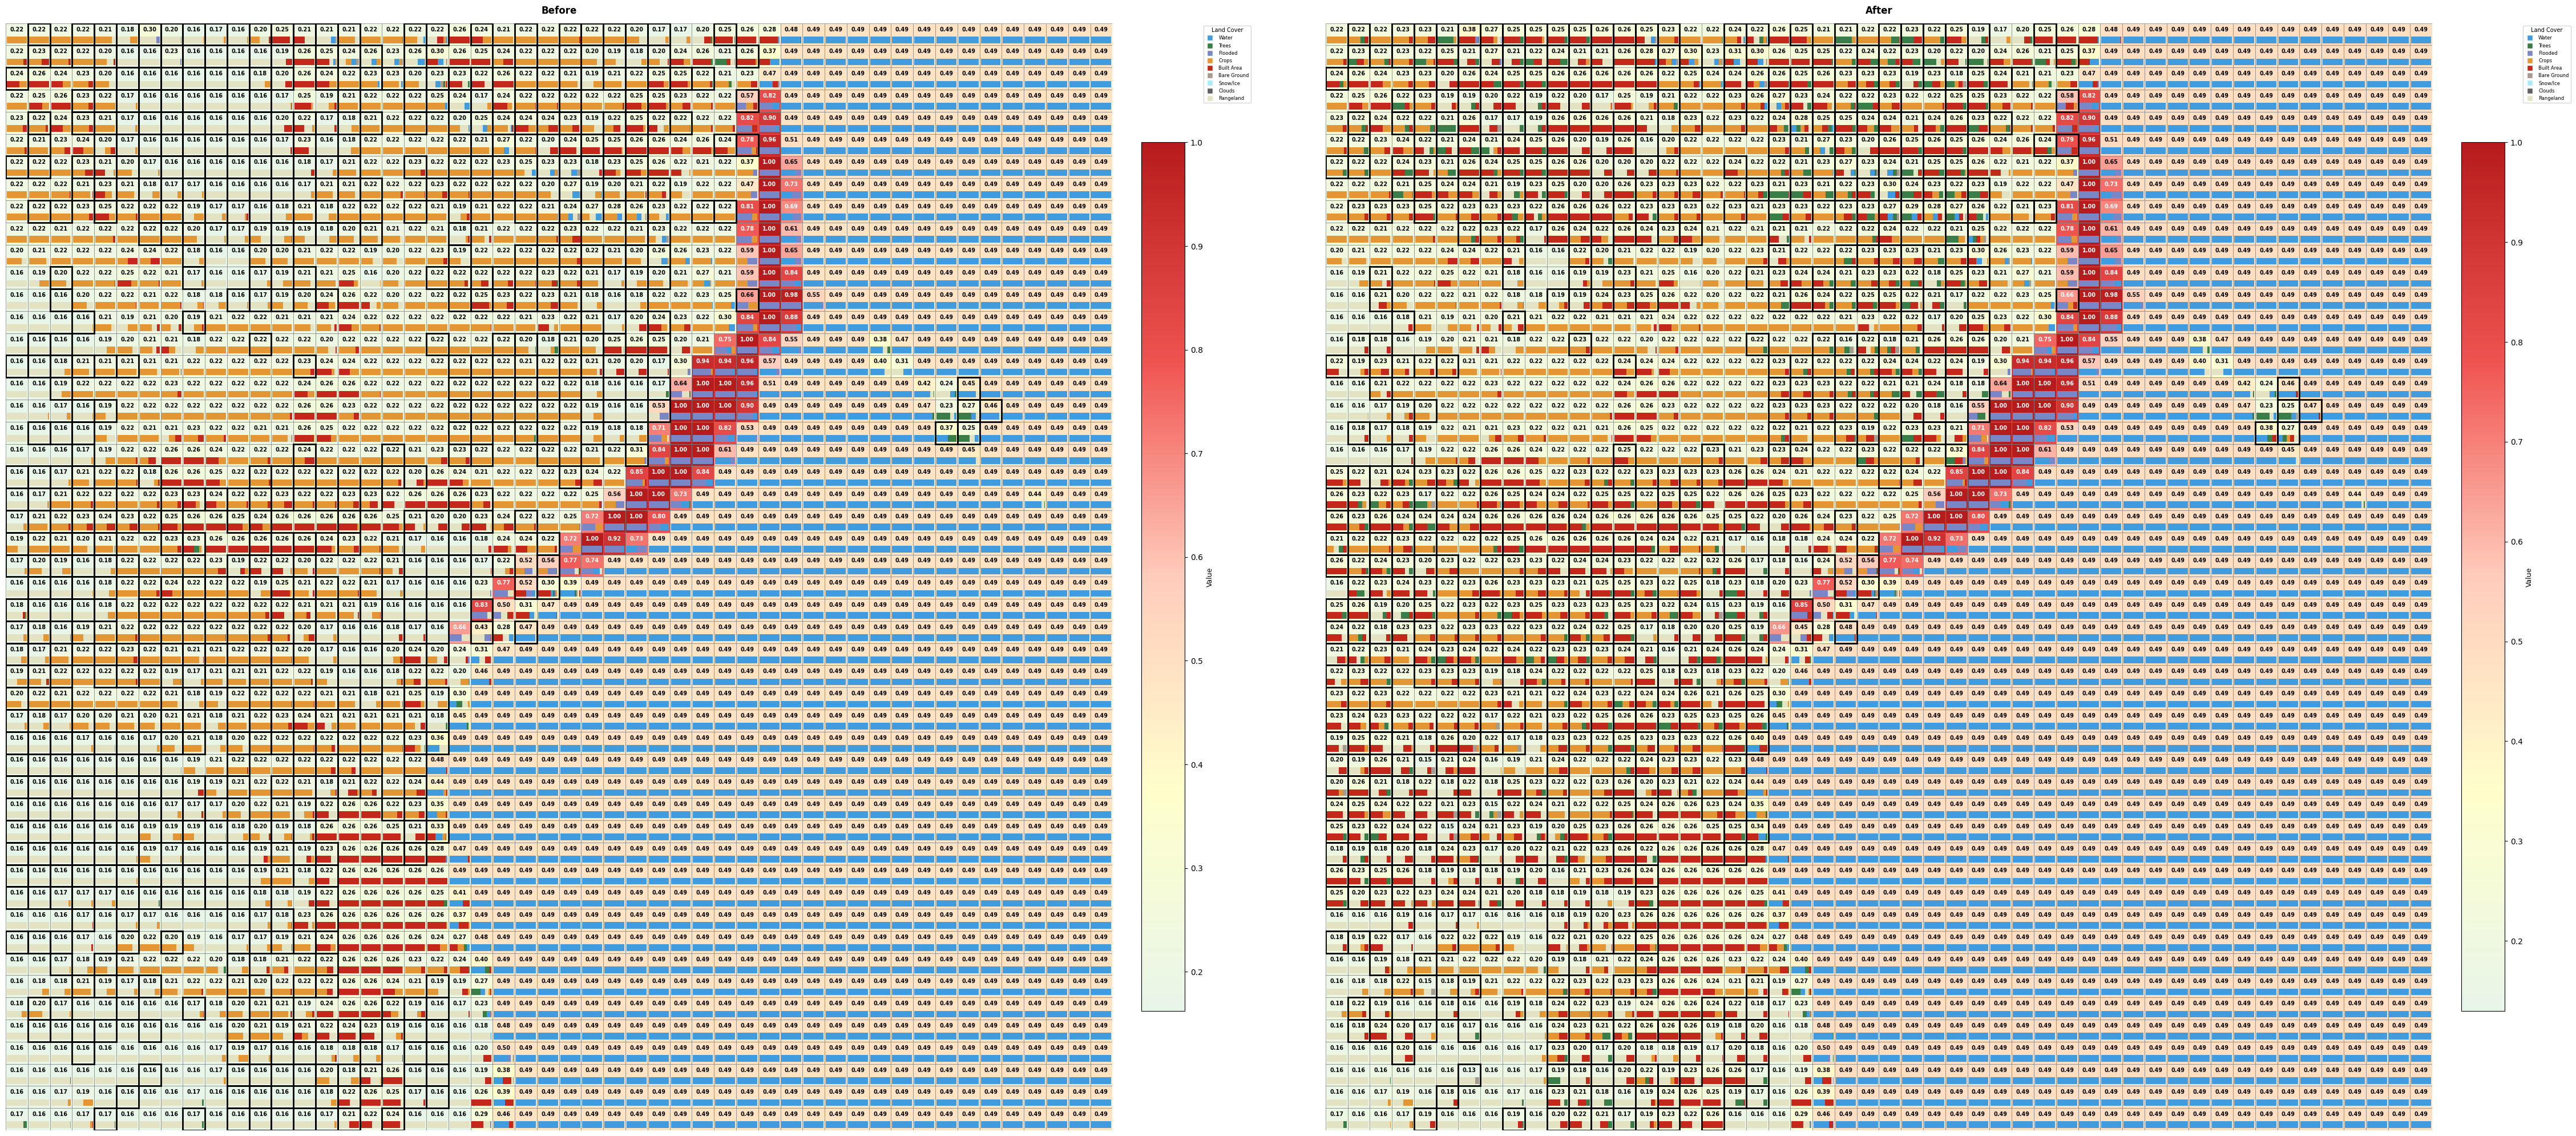

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from src.post_eda import plot_state_heatmap
plot_nm = "total_25w_V2_n_aug_5_transfer_5_new_eco_inital_spatial_rwd"

# value_per_class is your ECO_PER_CLASS + ET_PER_CLASS (shape N_CLASSES)
value_vec = ECO_PER_CLASS + ET_PER_CLASS

# Side-by-side comparison (both in fraction space)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(50, 20))
plot_state_heatmap(initial_obs, value_vec, title="Before", ax=ax1)
plot_state_heatmap(final_obs_recst, value_vec, title="After", ax=ax2)

# Highlight individual cells that changed (unique row, col from diffs)
n_rows = initial_obs.shape[0]
changed_cells = set((r, c) for r, c, *_ in diffs)
for (r, c) in changed_cells:
    for ax in (ax1, ax2):
        rect = patches.Rectangle(
            (c, n_rows - 1 - r), 1, 1,
            linewidth=2, edgecolor='black', facecolor='none'
        )
        ax.add_patch(rect)

plt.savefig(Path(data_dir, "processed", f"{plot_nm}.png"), dpi=200, bbox_inches="tight")